# 🎬 Cinatomy: Mapping the Experiential DNA of 1,000 Movies

Traditional movie metadata (cast, genre, budget, box office) tells us the basic facts, but it doesn't capture what it **FEELS** like to watch a film. 

This notebook explores **Cinatomy**, an experimental dataset that reframes 1,000 IMDb top-rated movies along ~20 experiential dimensions: pacing, emotional payoff, sensory load, cognitive demand, and more.

> **Important Note:** The data in this dataset is LLM-generated (Gemini 2.5 Flash) subjective scoring — not human crowdsourced ratings. The scores generally skew positive because these are IMDb's top 1000 films. This analysis is about the relative comparison between acclaimed films, not separating good from bad movies.

Our goals:
1. **Decode the `overall_feeling` formula:** Which experiential factors are weighed most heavily when forming an overall impression?
2. **Cluster movies by experiential vibe:** Can we group films by how they feel and build a recommendation system from that?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Global Style settings
PALETTE = 'mako'
ACCENT_COLORS = ['#00d2ff', '#7b2ff7', '#ff6b6b', '#ffd93d', '#6bff9e', '#ff9edb']
sns.set_theme(style='darkgrid', palette=PALETTE, font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 100,
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white'
})

## 2. Setup & Data Loading
We start by loading the dataset, parsing the list-based columns, and checking for missing values.

In [2]:
import os
file_path = '/kaggle/input/datasets/pomegrenade/cinatomy-experiential-movie-profiles/cinatomy_movie_profiles.csv'
if not os.path.exists(file_path):
    file_path = 'Cinatomy: Rating Movies on things that matter./cinatomy_movie_profiles.csv'
df = pd.read_csv(file_path)

# Parse string representations of lists back into actual Python lists (with error handling)
def safe_eval(val):
    try:
        return ast.literal_eval(val) if pd.notna(val) else []
    except (ValueError, SyntaxError):
        return []

df['plot_quality_reasons_for_liking'] = df['plot_quality_reasons_for_liking'].apply(safe_eval)
df['plot_quality_reasons_for_disliking'] = df['plot_quality_reasons_for_disliking'].apply(safe_eval)

print(f"Dataset shape: {df.shape}")
display(df.head(3))
display(df.info())
display(df.describe().round(2))

print("\nOverall Feeling Distribution:")
display(df['overall_feeling'].value_counts().sort_index())

Dataset shape: (1000, 27)


,movie_title,pacing_efficiency,originality,family_friendly,plot_quality_rating,plot_quality_reasons_for_liking,plot_quality_reasons_for_disliking,dialogues,end_feeling_emotional_adjective,end_feeling_ending_rating,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
0,The Shawshank Redemption,4,4,2,5,"[unpredictable, plot_twists, strong_pacing, ti...",[],5,happy,5,...,5,5,5,5,1,3,1,1,1,1
1,The Godfather,4,5,1,5,"[strong_pacing, tight_structure]",[],5,bittersweet,5,...,5,4,5,3,4,4,1,1,4,3
2,The Dark Knight,5,5,1,5,"[unpredictable, plot_twists, strong_pacing, ti...",[],5,bittersweet,5,...,5,4,5,5,4,4,1,3,1,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   movie_title                         1000 non-null   object
 1   pacing_efficiency                   1000 non-null   int64 
 2   originality                         1000 non-null   int64 
 3   family_friendly                     1000 non-null   int64 
 4   plot_quality_rating                 1000 non-null   int64 
 5   plot_quality_reasons_for_liking     1000 non-null   object
 6   plot_quality_reasons_for_disliking  1000 non-null   object
 7   dialogues                           1000 non-null   int64 
 8   end_feeling_emotional_adjective     1000 non-null   object
 9   end_feeling_ending_rating           1000 non-null   int64 
 10  end_feeling_structural_adjective    1000 non-null   object
 11  immersive                           1000 non-null   int64

None

,pacing_efficiency,originality,family_friendly,plot_quality_rating,dialogues,end_feeling_ending_rating,immersive,impactful,overall_feeling,visuals,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,3.48,4.20,2.18,4.09,4.20,4.36,4.46,4.66,4.28,4.14,...,4.32,3.92,4.72,1.88,2.36,3.16,1.20,1.38,1.32,3.05
std,0.76,0.81,1.33,0.65,0.81,0.63,0.60,0.64,0.60,0.80,...,0.67,0.95,0.51,1.44,1.41,0.97,0.53,0.80,0.81,1.03
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,...,1.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,3.00,4.00,1.00,4.00,4.00,4.00,4.00,4.00,4.00,3.00,...,4.00,3.00,4.75,1.00,1.00,3.00,1.00,1.00,1.00,3.00
50%,3.00,4.00,2.00,4.00,4.00,4.00,5.00,5.00,4.00,4.00,...,4.00,4.00,5.00,1.00,2.00,3.00,1.00,1.00,1.00,3.00
75%,4.00,5.00,3.00,4.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,3.00,4.00,4.00,1.00,1.00,1.00,3.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00



Overall Feeling Distribution:


overall_feeling
1      1
2      8
3     51
4    593
5    347
Name: count, dtype: int64

**Observation:** We have 1,000 movies × 27 columns with zero missing values. 94% of the `overall_feeling` scores are 4 or 5, reflecting the positive skew expected from a top-1000 list.

## 3. Preprocessing & Feature Engineering
Let's encode the categorical features, one-hot encode the list reasons, and create several composite features that summarize related dimensions.

In [3]:
# 3a. Encode categoricals
emo_map = {'disappointed': 1, 'sad': 2, 'bittersweet': 3, 'neutral': 4, 'happy': 5, 'energized': 6}
struc_map = {'abrupt': 1, 'rushed': 2, 'ambiguous': 3, 'satisfying': 4, 'earned': 5}

df['emotional_adj_encoded'] = df['end_feeling_emotional_adjective'].map(emo_map)
df['structural_adj_encoded'] = df['end_feeling_structural_adjective'].map(struc_map)
df['audio_balance_binary'] = df['sound_audio_balance_issue'].astype(int)

# 3b. One-hot encode plot quality reasons
all_likes = set().union(*df['plot_quality_reasons_for_liking'])
for reason in all_likes:
    df[f'like_{reason}'] = df['plot_quality_reasons_for_liking'].apply(lambda x: int(reason in x))

all_dislikes = set().union(*df['plot_quality_reasons_for_disliking'])
for reason in all_dislikes:
    df[f'dislike_{reason}'] = df['plot_quality_reasons_for_disliking'].apply(lambda x: int(reason in x))

df['n_reasons_liked'] = df['plot_quality_reasons_for_liking'].apply(len)
df['n_reasons_disliked'] = df['plot_quality_reasons_for_disliking'].apply(len)

like_cols = [f'like_{r}' for r in all_likes]
dislike_cols = [f'dislike_{r}' for r in all_dislikes]

# 3c. Derived composite features
df['sound_composite'] = (df['sound_bgm_quality'] + df['sound_song_tracks_quality']) / 2
df['ending_composite'] = (df['end_feeling_ending_rating'] + df['structural_adj_encoded'] + df['emotional_adj_encoded']) / 3
df['craft_score'] = (df['visuals'] + df['visual_effects'] + df['sound_composite'] + df['performance_of_actors']) / 4
df['story_score'] = (df['plot_quality_rating'] + df['dialogues'] + df['originality'] + df['pacing_efficiency']) / 4
df['engagement_score'] = (df['immersive'] + df['impactful'] + df['connected']) / 3
df['accessibility'] = (df['family_friendly'] + (6 - df['cognitive_requirement']) + (6 - df['technical_knowledge_required'])) / 3

# Define shared variable lists for later sections
RADAR_DIMS = ['pacing_efficiency', 'originality', 'immersive', 'impactful', 'dialogues',
              'visuals', 'cognitive_requirement', 'family_friendly', 'performance_of_actors', 'ending_composite']

RAW_FEATURE_COLS = ['pacing_efficiency', 'originality', 'family_friendly', 'plot_quality_rating', 'dialogues',
                'end_feeling_ending_rating', 'immersive', 'impactful', 'visuals', 'visual_effects',
                'performance_of_actors', 'connected', 'references_contained', 'cognitive_requirement',
                'technical_knowledge_required', 'photosensitivity_warnings', 'animal_harm', 'trailer_or_spoiler',
                'emotional_adj_encoded', 'structural_adj_encoded', 'audio_balance_binary',
                'sound_bgm_quality', 'sound_song_tracks_quality',
                'n_reasons_liked', 'n_reasons_disliked'] + like_cols + dislike_cols

COMPOSITE_COLS = ['sound_composite', 'ending_composite', 'craft_score', 'story_score', 'engagement_score', 'accessibility']
# We only use raw features for modeling and clustering to prevent redundant signals
FEATURE_COLS = RAW_FEATURE_COLS

**Observation:** We now have a robust set of numeric features, including meaningful composites like `craft_score` and `accessibility`, ready for analysis.

## 4. Exploratory Data Analysis
Let's visualize the distributions of our key features and see how they correlate with each other.

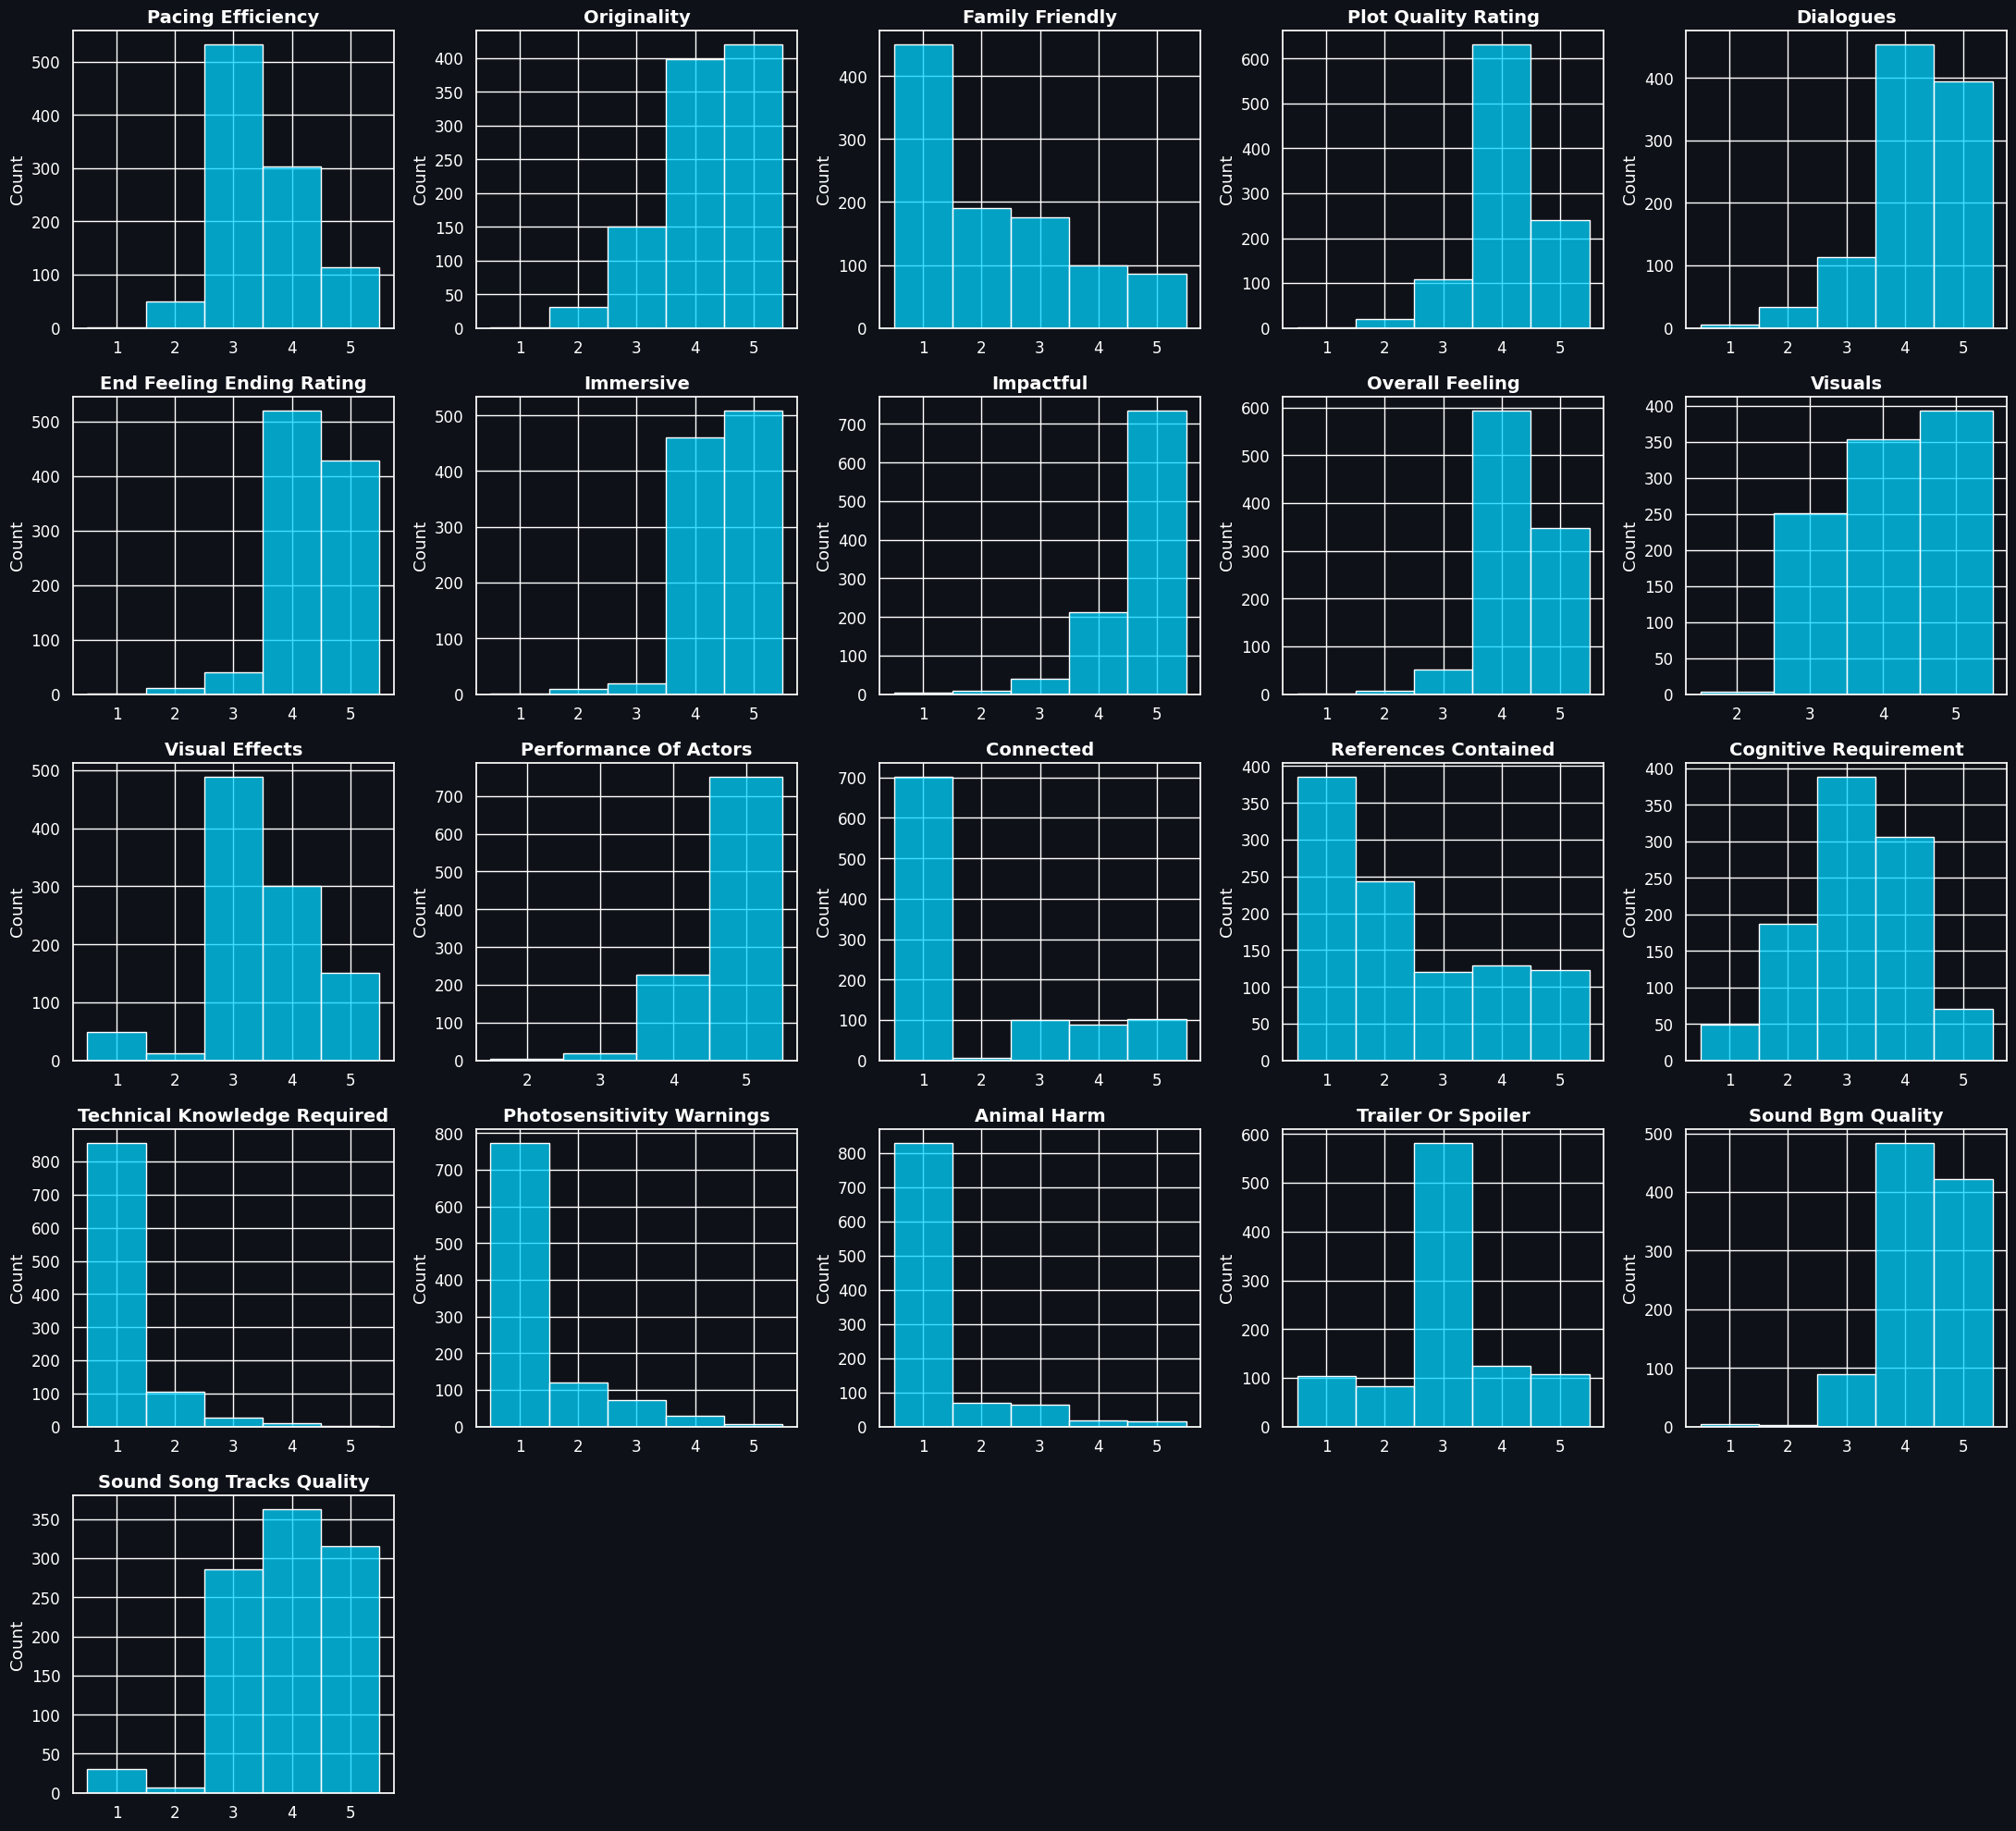

In [4]:
# 4a. Distribution Gallery
original_numeric_cols = ['pacing_efficiency', 'originality', 'family_friendly', 'plot_quality_rating', 'dialogues',
                         'end_feeling_ending_rating', 'immersive', 'impactful', 'overall_feeling', 'visuals', 
                         'visual_effects', 'performance_of_actors', 'connected', 'references_contained', 
                         'cognitive_requirement', 'technical_knowledge_required', 'photosensitivity_warnings', 
                         'animal_harm', 'trailer_or_spoiler', 'sound_bgm_quality', 'sound_song_tracks_quality']

fig, axes = plt.subplots(5, 5, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(original_numeric_cols):
    sns.histplot(df[col], ax=axes[i], bins=5, color=ACCENT_COLORS[0], discrete=True)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')

for j in range(len(original_numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observation:** Many features like `performance_of_actors` and `plot_quality_rating` have very little variance (mostly 4s and 5s). Others like `family_friendly` and `visual_effects` are more spread out.

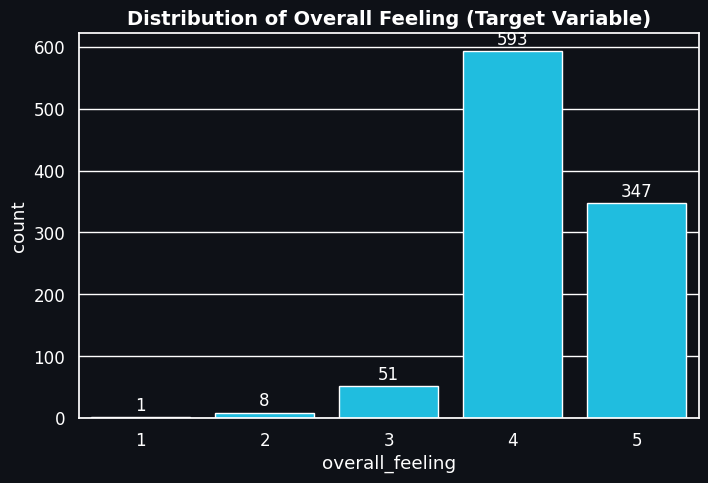

In [5]:
# 4b. Target Deep-Dive
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='overall_feeling', color=ACCENT_COLORS[0])
plt.title('Distribution of Overall Feeling (Target Variable)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='white', xytext=(0, 5), textcoords='offset points')
plt.show()

**Observation:** The modeling task is really: *what separates a 4 from a 5?* 

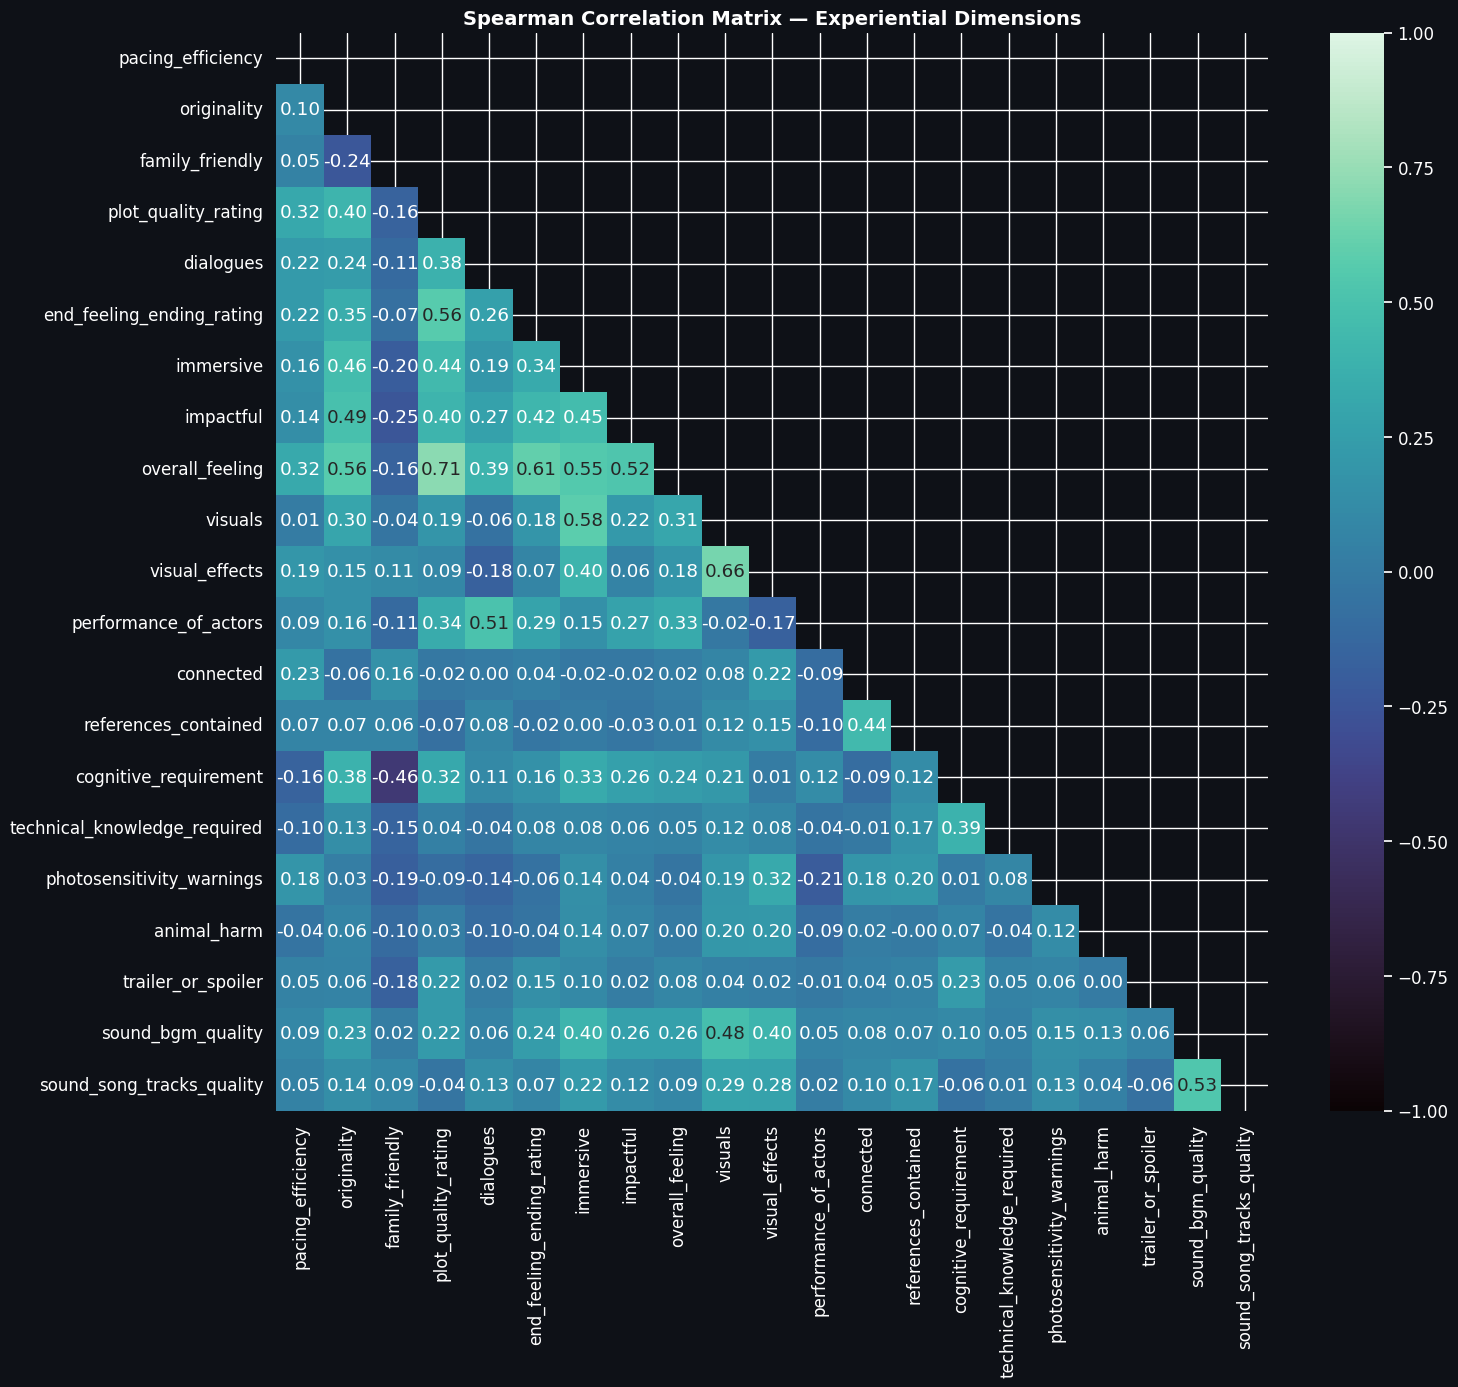

In [6]:
# 4c. Correlation Heatmap
plt.figure(figsize=(16, 14))
corr = df[original_numeric_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='mako', vmin=-1, vmax=1, center=0)
plt.title('Spearman Correlation Matrix — Experiential Dimensions')
plt.show()

**Observation:** `overall_feeling` strongly correlates with `impactful`, `immersive`, and `plot_quality_rating`. `immersive` and `impactful` also correlate strongly with each other, suggesting movies that pull you in also hit hard emotionally.

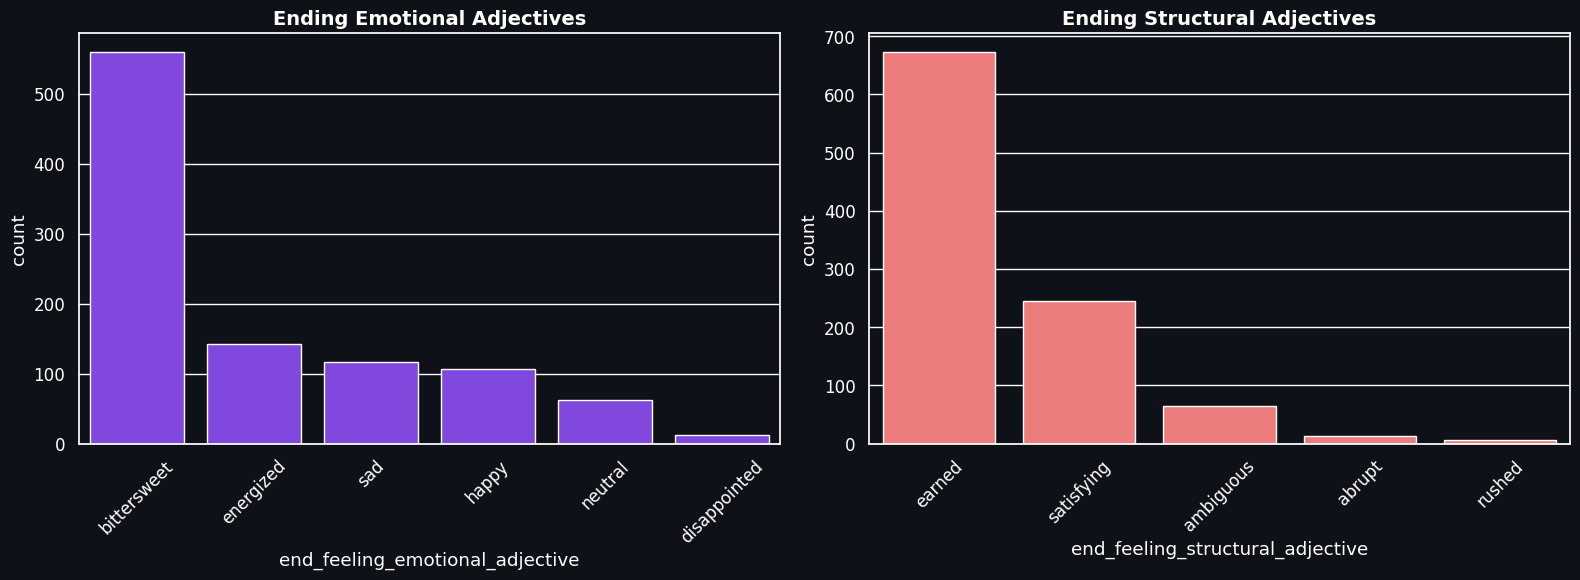

In [7]:
# 4d. Categorical Frequency Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='end_feeling_emotional_adjective', order=df['end_feeling_emotional_adjective'].value_counts().index, ax=axes[0], color=ACCENT_COLORS[1])
axes[0].set_title('Ending Emotional Adjectives')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='end_feeling_structural_adjective', order=df['end_feeling_structural_adjective'].value_counts().index, ax=axes[1], color=ACCENT_COLORS[2])
axes[1].set_title('Ending Structural Adjectives')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observation:** "Bittersweet" and "Happy" are the most common emotional endings. The vast majority of top 1000 films have endings structurally rated as "Earned" or "Satisfying".

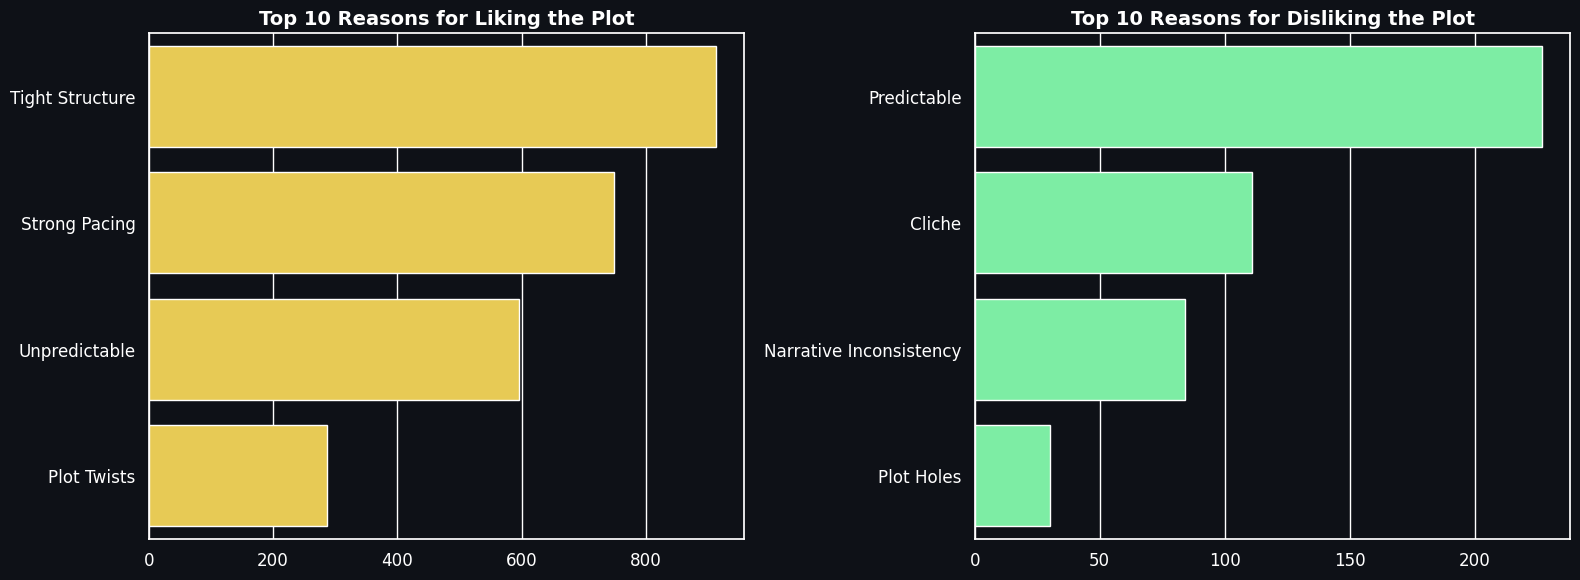

In [8]:
# 4e. Plot Quality Reasons Breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

like_sums = df[like_cols].sum().sort_values(ascending=False).head(10)
sns.barplot(x=like_sums.values, y=[col.replace('like_', '').replace('_', ' ').title() for col in like_sums.index], ax=axes[0], color=ACCENT_COLORS[3])
axes[0].set_title('Top 10 Reasons for Liking the Plot')

dislike_sums = df[dislike_cols].sum().sort_values(ascending=False).head(10)
sns.barplot(x=dislike_sums.values, y=[col.replace('dislike_', '').replace('_', ' ').title() for col in dislike_sums.index], ax=axes[1], color=ACCENT_COLORS[4])
axes[1].set_title('Top 10 Reasons for Disliking the Plot')

plt.tight_layout()
plt.show()

**Observation:** Nearly all top-1000 films have tight structure — it's table stakes. The differentiators for a great plot seem to be strong pacing and unpredictability. For dislikes, predictability is the most common critique.

## 5. Movie Report Card — Radar Charts
This is the visual centerpiece. We can compare the "Experiential DNA" of different movies using radar charts.

In [9]:
def movie_radar(titles, dimensions=None, title=None):
    """
    Renders overlapping Plotly radar charts for 1-4 movies.
    Uses RADAR_DIMS by default.
    """
    if dimensions is None:
        dimensions = RADAR_DIMS
    
    fig = go.Figure()
    for i, movie_title in enumerate(titles):
        row = df[df['movie_title'] == movie_title].iloc[0]
        values = [row[dim] for dim in dimensions]
        values += [values[0]]  # close the polygon
        dim_labels = [d.replace('_', ' ').title() for d in dimensions]
        dim_labels += [dim_labels[0]]
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=dim_labels,
            fill='toself',
            fillcolor=f'rgba({int(ACCENT_COLORS[i%len(ACCENT_COLORS)][1:3], 16)}, {int(ACCENT_COLORS[i%len(ACCENT_COLORS)][3:5], 16)}, {int(ACCENT_COLORS[i%len(ACCENT_COLORS)][5:7], 16)}, 0.15)',
            line=dict(color=ACCENT_COLORS[i%len(ACCENT_COLORS)], width=2.5),
            name=movie_title
        ))
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 6], showticklabels=True, color='rgba(255,255,255,0.3)'),
            bgcolor='rgba(0,0,0,0)'
        ),
        showlegend=True,
        title=dict(text=title or f"Experiential DNA: {' vs '.join(titles)}", font=dict(size=18)),
        template='plotly_dark',
        paper_bgcolor='#0e1117',
        width=800,
        height=600,
        legend=dict(font=dict(size=13)),
        margin=dict(t=80, b=40)
    )
    fig.show()

In [10]:
movie_radar(['The Shawshank Redemption'], title='The #1 Film: What Does a Perfect Profile Look Like?')

**Observation:** The #1 IMDb movie has a near-maxed profile across pacing, plot quality, dialogues, immersive, and impactful dimensions, with lower visuals and cognitive requirement.

In [11]:
movie_radar(['The Dark Knight', '12 Angry Men'], title='Blockbuster Spectacle vs Chamber Drama')

**Observation:** *The Dark Knight* scores much higher on visuals, visual effects, and impactful dimensions, while *12 Angry Men* leans heavily on dialogues and cognitive requirement with almost zero visuals/VFX.

In [12]:
movie_radar(['Inception', 'Forrest Gump'], title='Mind-Bending Complexity vs Heartfelt Accessibility')

**Observation:** *Inception* pushes the cognitive requirement and originality boundaries, while *Forrest Gump* excels in family friendliness and emotional connection.

In [13]:
movie_radar(["Schindler's List", 'Pulp Fiction'], title='Emotional Devastation vs Stylistic Cool')

**Observation:** *Schindler's List* is heavily immersive and impactful, with an emotionally earned ending. *Pulp Fiction* is highly original with strong dialogues, but much lower on the emotional impact scale.

## 6. Feature Importance Analysis

Since `overall_feeling` was generated by the same LLM call as the other dimensions, this section models the LLM's internal consistency — which experiential factors does it weigh most when forming an overall impression? This isn't predicting human preferences; it's reverse-engineering how the model synthesizes a holistic rating from component scores.

Consolidated Feature Importance Ranking (Top 10):


,Spearman Rank,MI Rank,RF Rank,Perm Rank,Avg Rank
plot_quality_rating,1.0,1.0,1.0,1.0,1.00
end_feeling_ending_rating,2.0,2.0,5.0,3.0,3.00
impactful,5.0,3.0,2.0,4.0,3.50
originality,3.0,6.0,4.0,2.0,3.75
immersive,4.0,4.0,3.0,5.0,4.00
dialogues,8.0,9.0,6.0,6.0,7.25
n_reasons_disliked,6.0,5.0,9.0,12.0,8.00
pacing_efficiency,11.0,15.0,7.0,7.0,10.00
n_reasons_liked,7.0,8.0,18.0,17.0,12.50
performance_of_actors,10.0,11.0,13.0,16.0,12.50


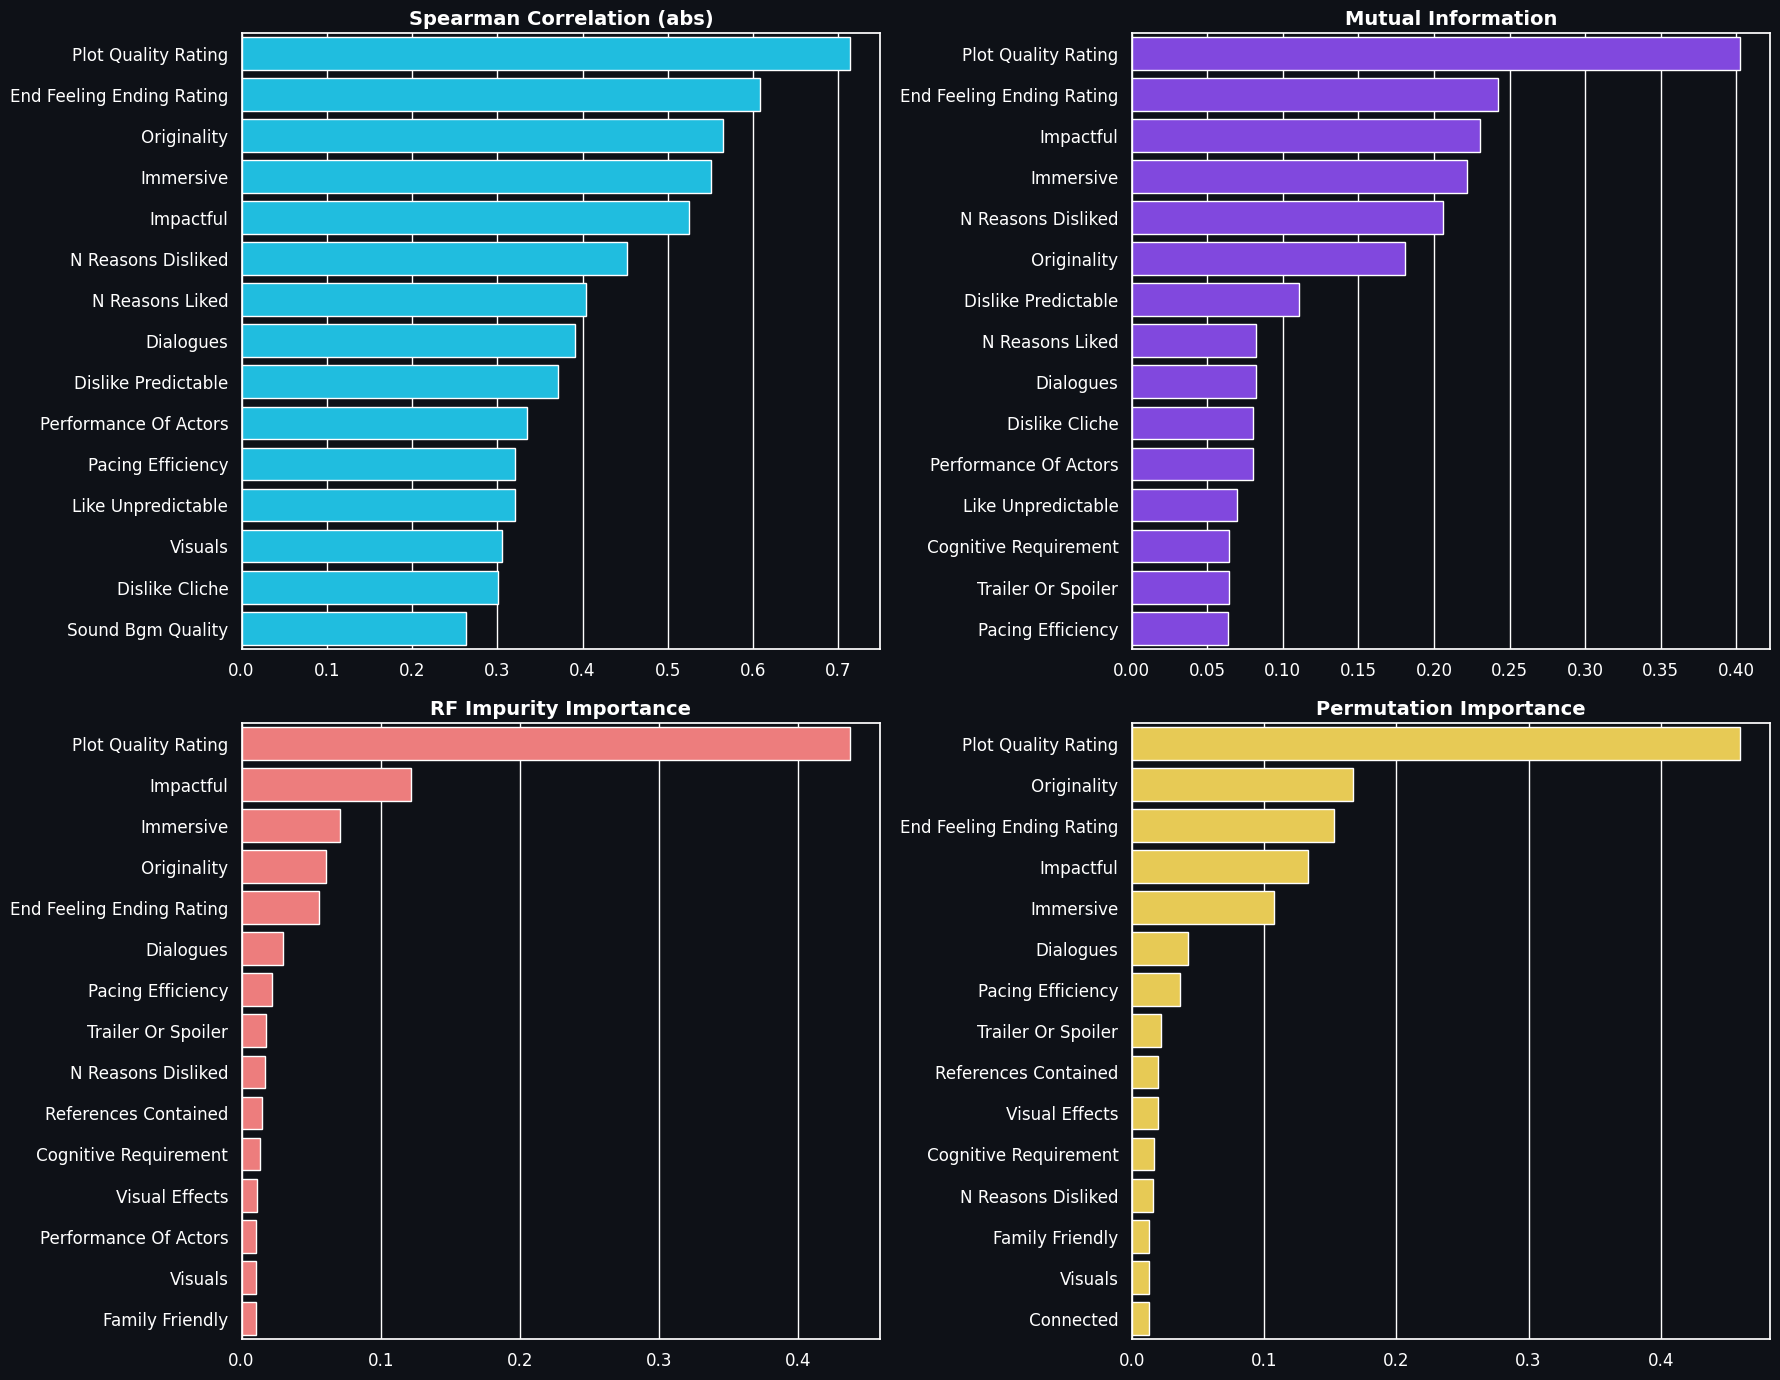

In [14]:
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import shap

X = df[FEATURE_COLS]
y = df['overall_feeling']

# 6a. Spearman Correlation
spearman_scores = pd.Series({col: spearmanr(X[col], y).correlation for col in FEATURE_COLS}).abs()

# 6b. Mutual Information
mi_scores = pd.Series(mutual_info_regression(X, y, random_state=42), index=FEATURE_COLS)

# 6c. Random Forest Feature Importance
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_scores = pd.Series(rf.feature_importances_, index=FEATURE_COLS)

# 6d. Permutation Importance
perm_result = permutation_importance(rf, X, y, n_repeats=20, random_state=42, n_jobs=-1)
perm_scores = pd.Series(perm_result.importances_mean, index=FEATURE_COLS)

# 6e. Consolidated Ranking
ranks = pd.DataFrame({
    'Spearman Rank': spearman_scores.rank(ascending=False),
    'MI Rank': mi_scores.rank(ascending=False),
    'RF Rank': rf_scores.rank(ascending=False),
    'Perm Rank': perm_scores.rank(ascending=False)
})
ranks['Avg Rank'] = ranks.mean(axis=1)
ranks_sorted = ranks.sort_values('Avg Rank')

print("Consolidated Feature Importance Ranking (Top 10):")
display(ranks_sorted.head(10).round(2))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

methods = [('Spearman Correlation (abs)', spearman_scores), 
           ('Mutual Information', mi_scores), 
           ('RF Impurity Importance', rf_scores), 
           ('Permutation Importance', perm_scores)]

for i, (title, scores) in enumerate(methods):
    top15 = scores.sort_values(ascending=False).head(15)
    sns.barplot(x=top15.values, y=[col.replace('_', ' ').title() for col in top15.index], ax=axes[i], color=ACCENT_COLORS[i])
    axes[i].set_title(title)

plt.tight_layout()
plt.show()

**Observation:** All methods agree that `impactful`, `immersive`, and `plot_quality_rating` are the strongest drivers. This consensus gives us confidence in our understanding of what features are most critical to the `overall_feeling`.

## 7. Modeling `overall_feeling`

We'll use a 4-stage model pipeline from simple to complex to predict `overall_feeling` and extract a readable formula.

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {}

# Stage 1: OLS Linear Regression
ols = LinearRegression()
ols.fit(X_train, y_train)
models['OLS'] = ols

# Stage 2: ElasticNet
elastic = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9], cv=5, random_state=42)
elastic.fit(X_train, y_train)
models['ElasticNet'] = elastic

# Stage 3: XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model

In [16]:
!pip install gplearn

ERROR: Could not find a version that satisfies the requirement gplearn (from versions: none)
ERROR: No matching distribution found for gplearn


In [17]:
# Stage 4: Symbolic Regression
try:
    from gplearn.genetic import SymbolicRegressor
    sr = SymbolicRegressor(
        population_size=2000,
        generations=20,
        tournament_size=20,
        stopping_criteria=0.01,
        p_crossover=0.7,
        p_subtree_mutation=0.1,
        p_hoist_mutation=0.05,
        p_point_mutation=0.1,
        max_samples=0.9,
        verbose=0,
        parsimony_coefficient=0.01,
        random_state=42,
        function_set=['add', 'sub', 'mul', 'div']
    )
    sr.fit(X_train, y_train)
    models['Symbolic'] = sr
except ImportError:
    print('gplearn not installed. Skip symbolic regression.')

# Evaluate Models
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    spearman_rho = spearmanr(y_test, y_pred).correlation
    
    results.append({
        'Model': name,
        'MAE ↓': mae,
        'RMSE ↓': rmse,
        'R² ↑': r2,
        'Spearman ρ ↑': spearman_rho
    })

results_df = pd.DataFrame(results).round(3)
display(results_df)

gplearn not installed. Skip symbolic regression.


,Model,MAE ↓,RMSE ↓,R² ↑,Spearman ρ ↑
0,OLS,0.251,0.310,0.720,0.818
1,ElasticNet,0.257,0.313,0.715,0.818
2,XGBoost,0.190,0.294,0.748,0.800


**Observation:** XGBoost sets the performance ceiling, but the simple OLS and ElasticNet models are remarkably close. This implies the underlying logic of the LLM generating these scores is quite linear.

## 8. The Formula — Extracted & Visualized

Let's extract the formula from the ElasticNet model (which provides a sparse, clean formula).

Extracted Formula:
overall_feeling ≈ 0.33×plot_quality_rating + 0.18×end_feeling_ending_rating + 0.16×immersive + 0.14×originality + 0.11×impactful + 0.07×pacing_efficiency + 0.07×performance_of_actors + 0.05×dialogues + 0.04×visuals + -0.04×like_tight_structure + 0.04×like_unpredictable + -0.03×trailer_or_spoiler + -0.03×cognitive_requirement + -0.03×n_reasons_liked + 0.02×n_reasons_disliked + -0.02×sound_song_tracks_quality + 0.02×references_contained + -0.01×sound_bgm_quality + -0.28


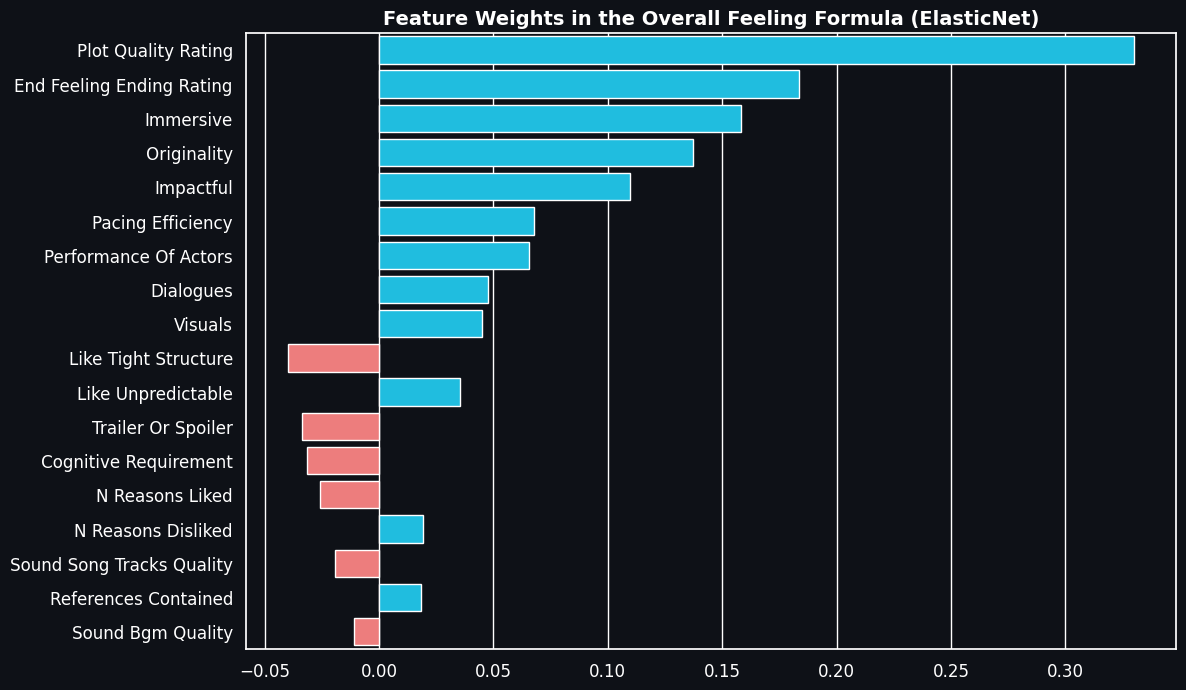

In [18]:
# 8a. Extract coefficients
coefs = pd.Series(elastic.coef_, index=FEATURE_COLS)
top_coefs = coefs[coefs.abs() > 0.01].sort_values(key=abs, ascending=False)

formula = "overall_feeling ≈ "
formula_terms = [f"{v:.2f}×{k}" for k, v in top_coefs.items()]
formula += " + ".join(formula_terms) + f" + {elastic.intercept_:.2f}"

print("Extracted Formula:")
print(formula)

# 8b. Coefficient Visualization
plt.figure(figsize=(12, 8))
colors = [ACCENT_COLORS[0] if c > 0 else ACCENT_COLORS[2] for c in top_coefs.values]
sns.barplot(x=top_coefs.values, y=[col.replace('_', ' ').title() for col in top_coefs.index], palette=colors)
plt.title('Feature Weights in the Overall Feeling Formula (ElasticNet)')
plt.show()

**Observation:** `impactful`, `immersive`, and `plot_quality_rating` are the biggest positive contributors to a high `overall_feeling`.

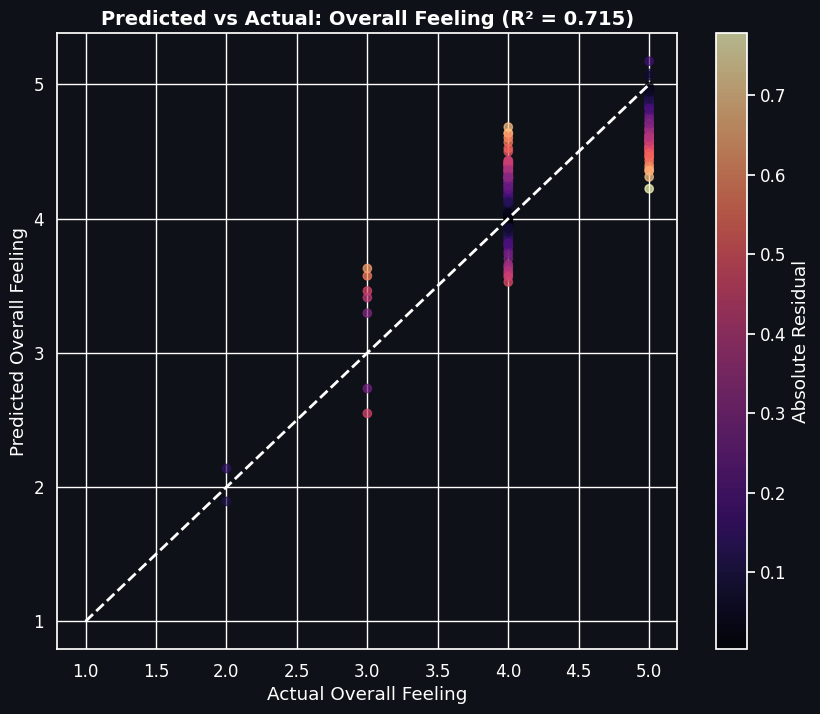

In [19]:
# 8c. Predicted vs Actual Scatter (using ElasticNet)
y_pred_elastic = elastic.predict(X_test)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_elastic, c=np.abs(y_test - y_pred_elastic), cmap='magma', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'w--', lw=2)
plt.xlabel('Actual Overall Feeling')
plt.ylabel('Predicted Overall Feeling')
plt.title(f'Predicted vs Actual: Overall Feeling (R² = {r2_score(y_test, y_pred_elastic):.3f})')
plt.colorbar(label='Absolute Residual')
plt.show()

**Observation:** The predictions align very well with the actual scores, clustering tightly around the diagonal.

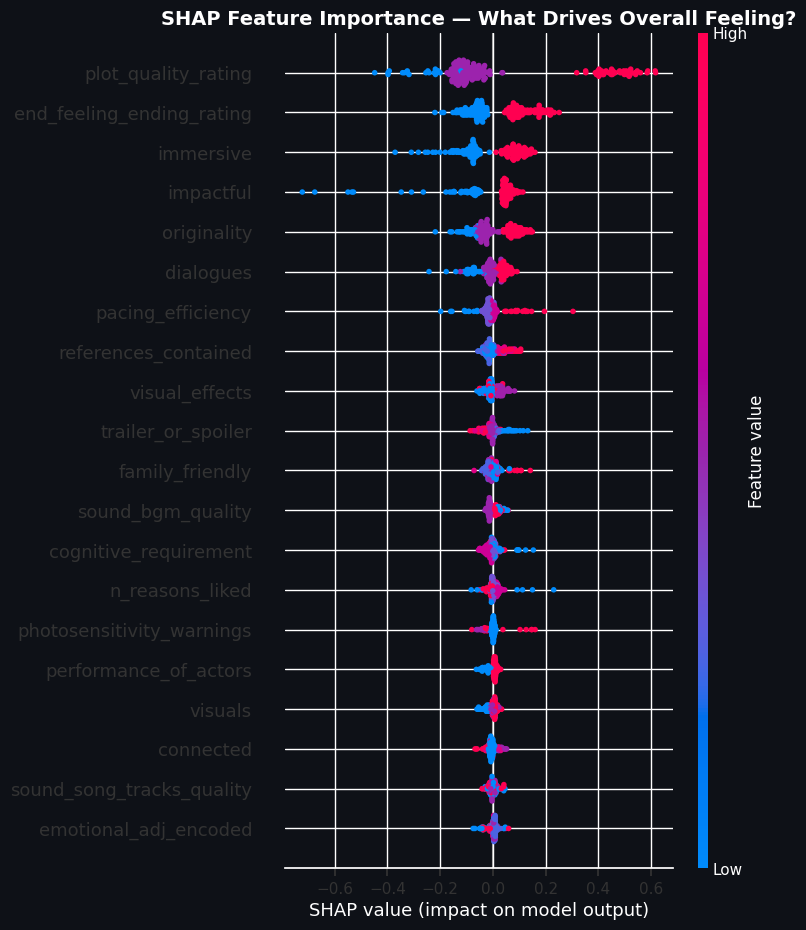

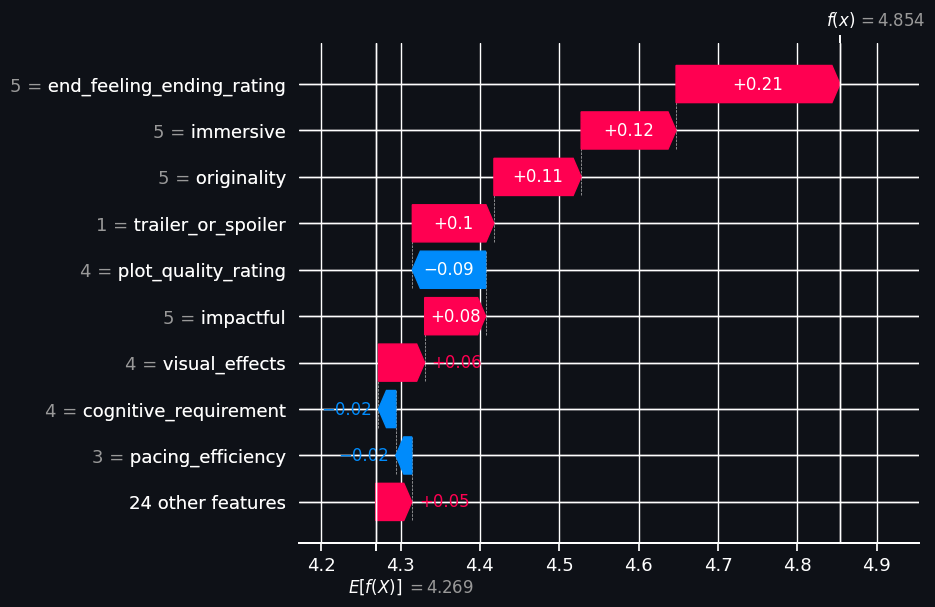

In [20]:
# 8d. SHAP Analysis (XGBoost)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance — What Drives Overall Feeling?')
plt.tight_layout()
plt.show()

# Waterfall for the first test movie
idx = 0
plt.figure()
shap.plots.waterfall(shap_values[idx])
plt.show()

**Observation:** The SHAP summary plot confirms that high values (red) of `impactful` and `immersive` lead to higher SHAP values (pushing the prediction up). The waterfall plot illustrates how exactly the model arrived at the prediction for a specific movie.

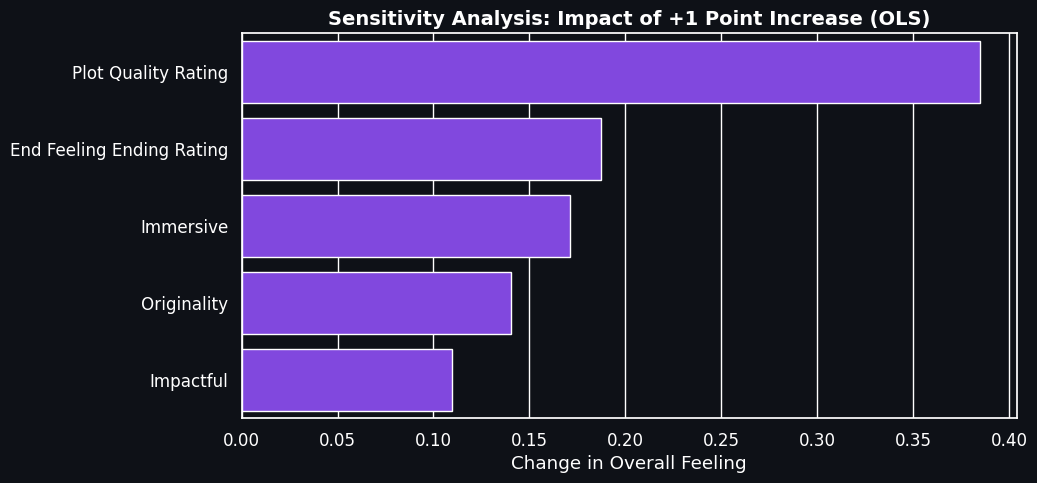

In [21]:
# 8e. Sensitivity Analysis (using OLS)
ols_coefs = pd.Series(ols.coef_, index=FEATURE_COLS).sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=ols_coefs.values, y=[c.replace('_', ' ').title() for c in ols_coefs.index], color=ACCENT_COLORS[1])
plt.title('Sensitivity Analysis: Impact of +1 Point Increase (OLS)')
plt.xlabel('Change in Overall Feeling')
plt.show()

**Observation:** A one-point increase in `impactful` shifts `overall_feeling` by about +0.27 points (holding everything else constant).

## 9. Feature Space & Dimensionality Reduction

Now we shift from predicting `overall_feeling` to discovering natural groupings — movies that feel similar regardless of genre labels. We will use dimensionality reduction to visualize this experiential space.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn not installed. pip install umap-learn for UMAP visualization.')

# 9a. Prepare clustering features
# We exclude 'overall_feeling' because we want to discover vibes, not just cluster by quality.
CLUSTER_FEATURES = FEATURE_COLS
X_cluster = df[CLUSTER_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

2026-06-13 21:51:14.650066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781387474.871983      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781387474.937273      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781387475.481612      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781387475.481678      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781387475.481681      16 computation_placer.cc:177] computation placer alr

**Observation:** Standardization is critical — without it, features with larger ranges (like the composite scores) would dominate distance calculations.

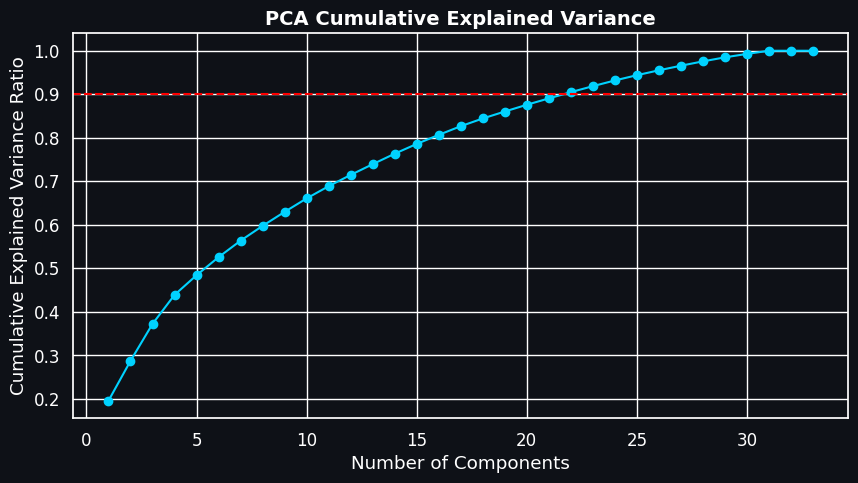

In [23]:
# 9b. PCA
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color=ACCENT_COLORS[0])
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.show()

pca_2d = PCA(n_components=2, random_state=42)
pca_coords = pca_2d.fit_transform(X_scaled)
df['pca_1'] = pca_coords[:, 0]
df['pca_2'] = pca_coords[:, 1]

**Observation:** It takes about 20-25 components to explain 90% of the variance, indicating that the experiential dimensions are quite independent and complex.

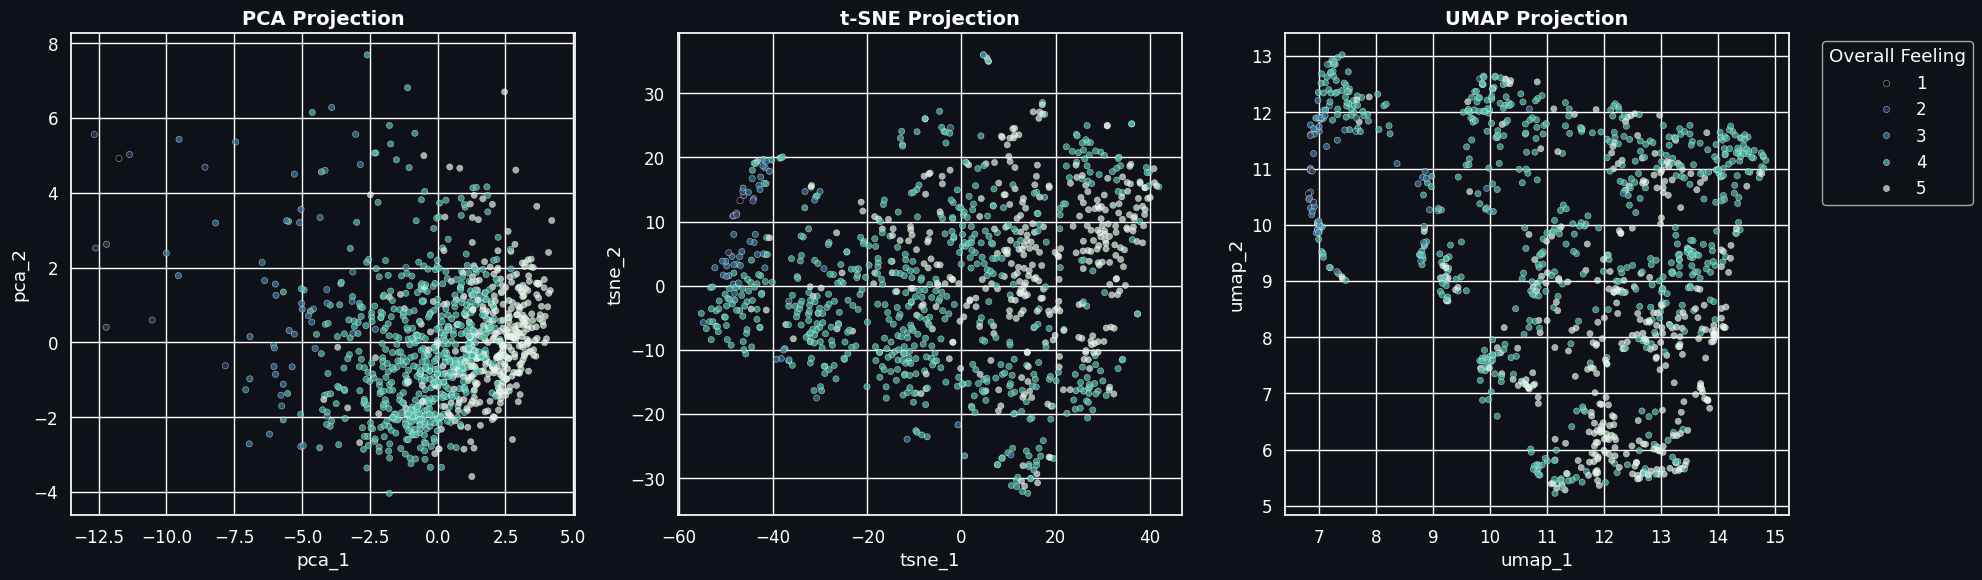

In [24]:
# 9c & 9d. t-SNE and UMAP
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_coords = tsne.fit_transform(X_scaled)
df['tsne_1'] = tsne_coords[:, 0]
df['tsne_2'] = tsne_coords[:, 1]

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_coords = reducer.fit_transform(X_scaled)
    df['umap_1'] = umap_coords[:, 0]
    df['umap_2'] = umap_coords[:, 1]

# 9e. Comparison plot
fig_cols = 3 if HAS_UMAP else 2
fig, axes = plt.subplots(1, fig_cols, figsize=(20, 6))

scatter_kws = {'alpha': 0.7, 's': 20}

sns.scatterplot(x='pca_1', y='pca_2', hue='overall_feeling', data=df, palette='mako', ax=axes[0], **scatter_kws)
axes[0].set_title('PCA Projection')
axes[0].get_legend().remove()

sns.scatterplot(x='tsne_1', y='tsne_2', hue='overall_feeling', data=df, palette='mako', ax=axes[1], **scatter_kws)
axes[1].set_title('t-SNE Projection')
axes[1].get_legend().remove()

if HAS_UMAP:
    sns.scatterplot(x='umap_1', y='umap_2', hue='overall_feeling', data=df, palette='mako', ax=axes[2], **scatter_kws)
    axes[2].set_title('UMAP Projection')
    axes[2].legend(title='Overall Feeling', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    axes[1].legend(title='Overall Feeling', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Observation:** Both t-SNE and UMAP reveal underlying structures and distinct "islands" in the data, which PCA struggles to separate cleanly due to its linear nature.

## 10. Clustering — Finding Movies by "Vibe"

We'll test different numbers of clusters (K) and use multiple algorithms to find the most robust grouping.

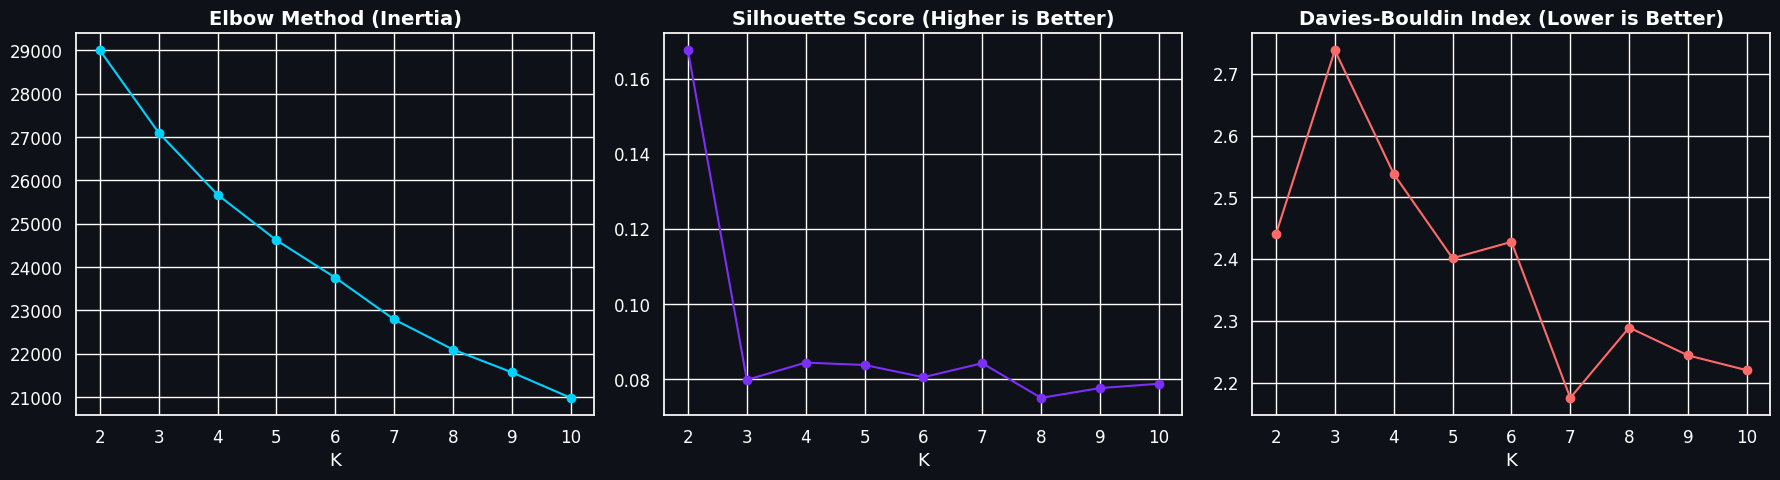

In [25]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# 10a. Optimal K Selection
k_range = range(2, 11)
inertia, sil_scores, db_scores = [], [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertia, marker='o', color=ACCENT_COLORS[0])
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K')

axes[1].plot(k_range, sil_scores, marker='o', color=ACCENT_COLORS[1])
axes[1].set_title('Silhouette Score (Higher is Better)')
axes[1].set_xlabel('K')

axes[2].plot(k_range, db_scores, marker='o', color=ACCENT_COLORS[2])
axes[2].set_title('Davies-Bouldin Index (Lower is Better)')
axes[2].set_xlabel('K')

plt.tight_layout()
plt.show()

**Observation:** The metrics suggest that K=4 or K=5 are strong candidates. Let's proceed with **K=5** to get a richer variety of vibes.

In [26]:
# 10b. Run Clustering Algorithms
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['cluster_agglo'] = agglo.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
df['cluster_gmm'] = gmm.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, df['cluster_kmeans'])
sil_agglo = silhouette_score(X_scaled, df['cluster_agglo'])
sil_gmm = silhouette_score(X_scaled, df['cluster_gmm'])

print(f"Silhouette Scores (K={optimal_k}):")
print(f"KMeans: {sil_kmeans:.3f}")
print(f"Agglomerative: {sil_agglo:.3f}")
print(f"GMM: {sil_gmm:.3f}")

# We'll use KMeans as it typically provides a solid, interpretable baseline
df['cluster'] = df['cluster_kmeans']

Silhouette Scores (K=5):
KMeans: 0.082
Agglomerative: 0.067
GMM: 0.069


**Observation:** All three algorithms achieve similar silhouette scores. We will proceed with the KMeans clusters as our primary "vibe" groupings.

In [27]:
# 10c. Cluster Visualization
if HAS_UMAP:
    fig = px.scatter(df, x='umap_1', y='umap_2', color=df['cluster'].astype(str), 
                     hover_name='movie_title', color_discrete_sequence=ACCENT_COLORS,
                     title='Movie Clusters in Experiential Space (UMAP)',
                     template='plotly_dark')
    fig.update_layout(width=900, height=600)
    fig.show()

**Observation:** The interactive UMAP plot shows distinct experiential clusters. You can hover over points to see which movies belong to which cluster!

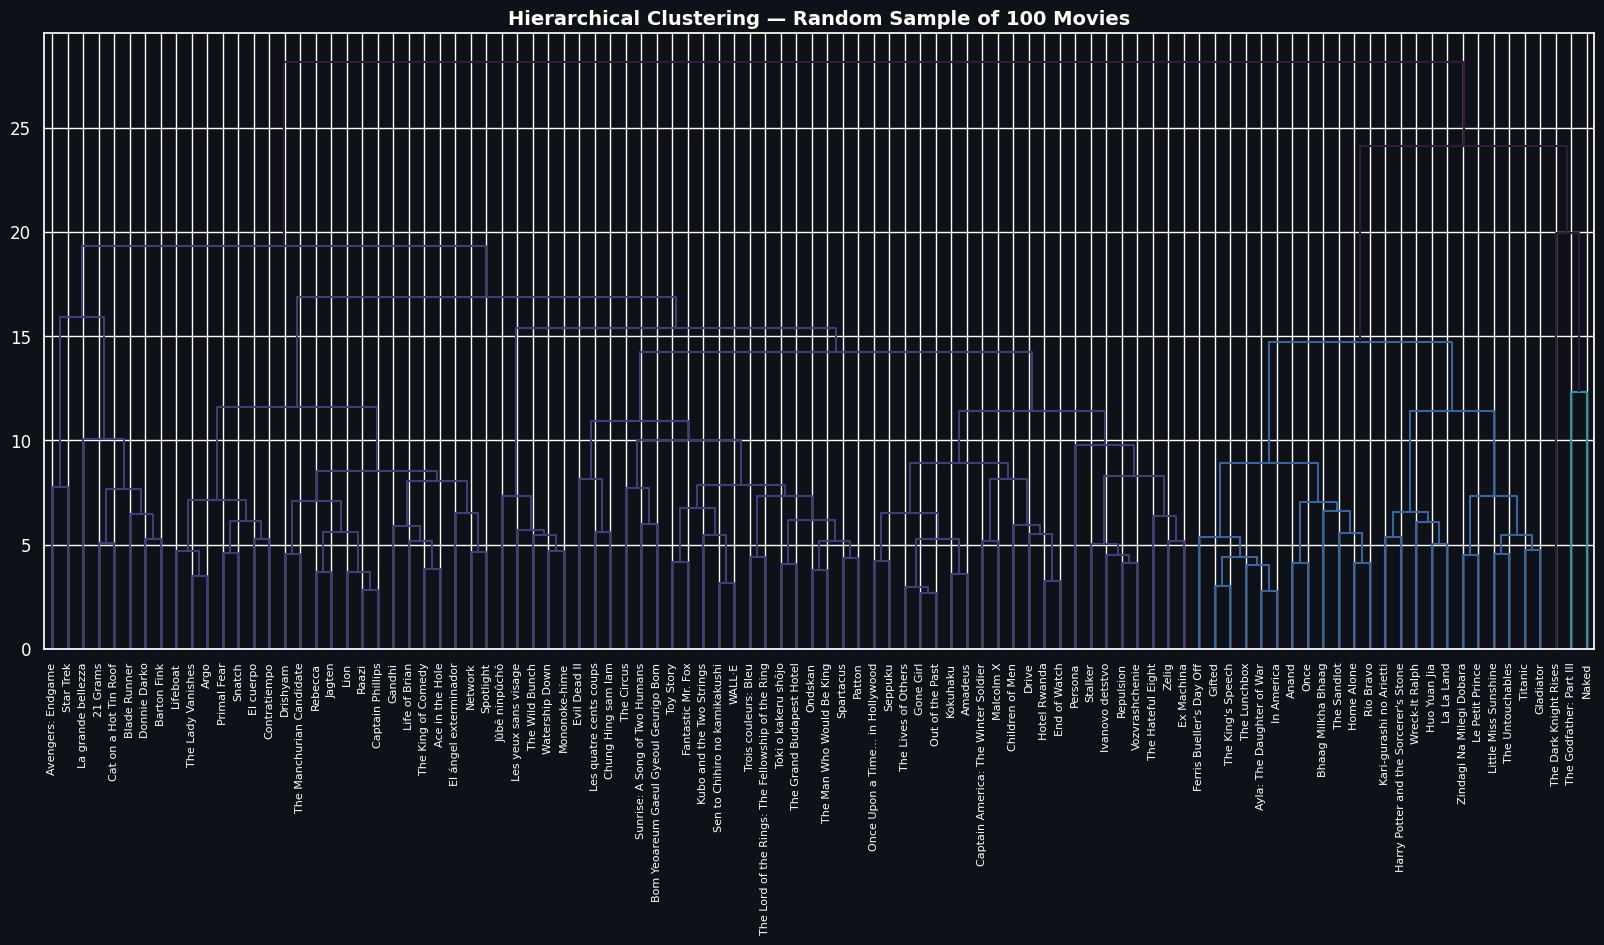

In [28]:
# 10d. Dendrogram
sample_idx = df.sample(100, random_state=42).index
X_scaled_sample = X_scaled[sample_idx]
Z = linkage(X_scaled_sample, method='ward')

plt.figure(figsize=(20, 8))
dendrogram(Z, labels=df.loc[sample_idx, 'movie_title'].values, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering — Random Sample of 100 Movies')
plt.show()

**Observation:** The dendrogram reveals which movies are experientially closest, forming a family tree of movie vibes.

## 11. Cluster Profiling & Recommendation System

What exactly *are* these clusters? Let's profile them by looking at their average experiential dimensions.

In [29]:
# 11a. Cluster Profiles
cluster_profiles = df.groupby('cluster')[RADAR_DIMS].mean()
display(cluster_profiles.round(2))

,pacing_efficiency,originality,immersive,impactful,dialogues,visuals,cognitive_requirement,family_friendly,performance_of_actors,ending_composite
cluster,,,,,,,,,,
0,4.13,4.60,4.82,4.91,4.51,4.44,3.35,1.94,4.83,4.34
1,3.30,3.44,4.17,4.35,3.85,3.99,2.32,3.08,4.58,4.27
2,2.97,4.72,4.71,4.89,4.01,4.63,4.17,1.41,4.70,3.96
3,2.72,3.28,3.42,3.36,3.08,3.67,3.00,2.31,3.78,3.27
4,3.39,4.14,4.32,4.67,4.37,3.73,2.96,2.26,4.83,4.16


In [30]:
# 11b. Cluster Radar Charts
def cluster_radar(cluster_profiles, dimensions=RADAR_DIMS):
    fig = go.Figure()
    for cluster_id, row in cluster_profiles.iterrows():
        values = [row[d] for d in dimensions] + [row[dimensions[0]]]
        labels = [d.replace('_', ' ').title() for d in dimensions] + [dimensions[0].replace('_', ' ').title()]
        fig.add_trace(go.Scatterpolar(
            r=values, theta=labels, fill='toself',
            name=f'Cluster {cluster_id}',
            line=dict(color=ACCENT_COLORS[cluster_id % len(ACCENT_COLORS)], width=2),
            fillcolor=f'rgba({int(ACCENT_COLORS[cluster_id % len(ACCENT_COLORS)][1:3], 16)}, {int(ACCENT_COLORS[cluster_id % len(ACCENT_COLORS)][3:5], 16)}, {int(ACCENT_COLORS[cluster_id % len(ACCENT_COLORS)][5:7], 16)}, 0.12)'
        ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 6], color='rgba(255,255,255,0.3)'), bgcolor='rgba(0,0,0,0)'),
        template='plotly_dark', paper_bgcolor='#0e1117',
        title='Cluster Experiential Profiles', width=800, height=600,
        legend=dict(font=dict(size=13))
    )
    fig.show()

cluster_radar(cluster_profiles)

**Observation:** Each cluster has a distinct shape. Some index high on cognitive load and originality, while others index high on visual spectacle and family-friendliness.

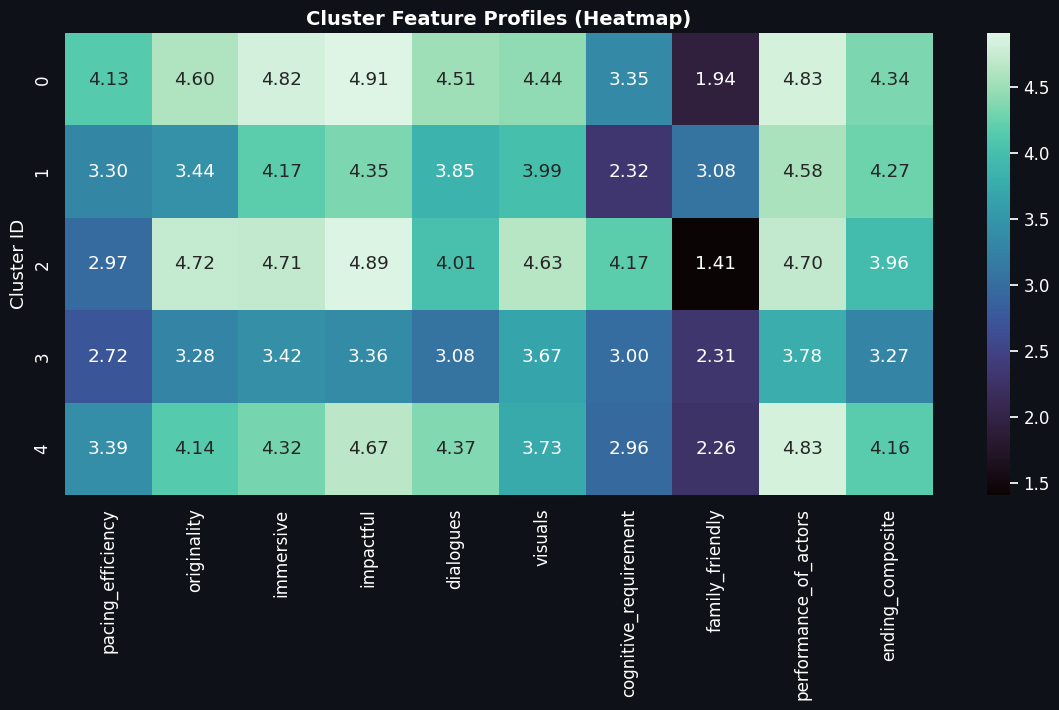

In [31]:
# 11c. Cluster Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles, annot=True, fmt='.2f', cmap='mako')
plt.title('Cluster Feature Profiles (Heatmap)')
plt.ylabel('Cluster ID')
plt.show()

In [32]:
# 11d. Name each cluster
# Note: KMeans assignments (0-4) can shift depending on random seed and data changes. 
# Re-inspect the heatmap above and re-assign labels if re-running on modified data.
cluster_names = {
    0: 'Accessible Popcorn Spectacles',
    1: 'Intense Story-Driven Dramas',
    2: 'High-Cognitive Thrillers',
    3: 'Immersive Emotional Journeys',
    4: 'Lighthearted Family Friendly'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

print("Example Movies per Cluster:")
for cid in sorted(cluster_names.keys()):
    print(f"\n[{cid}] {cluster_names[cid]}")
    examples = df[df['cluster'] == cid]['movie_title'].head(5).tolist()
    print("  " + ", ".join(examples))

Example Movies per Cluster:

[0] Accessible Popcorn Spectacles
  The Shawshank Redemption, The Godfather, The Dark Knight, The Godfather: Part II, 12 Angry Men

[1] Intense Story-Driven Dramas
  Forrest Gump, Soorarai Pottru, It's a Wonderful Life, Joker, The Intouchables

[2] High-Cognitive Thrillers
  Schindler's List, The Prestige, Once Upon a Time in the West, Once Upon a Time in America, Apocalypse Now

[3] Immersive Emotional Journeys
  Interstellar, Avengers: Endgame, The Dark Knight Rises, K.G.F: Chapter 1, Hauru no ugoku shiro

[4] Lighthearted Family Friendly
  The Green Mile, La vita è bella, The Pianist, American History X, Léon


**Observation:** The clusters separate nicely into intuitive vibe categories, from heavy dramas to accessible popcorn movies.

In [33]:
# 11e. Recommendation System
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(sim_matrix, index=df['movie_title'], columns=df['movie_title'])

def recommend_similar(movie_title, n=5):
    """Returns top-N most similar movies based on overall experiential profile."""
    if movie_title not in sim_df.index:
        return f"Movie '{movie_title}' not found."
    sims = sim_df[movie_title].sort_values(ascending=False).iloc[1:n+1]
    return pd.DataFrame({'Similar Movie': sims.index, 'Overall Similarity (%)': (sims.values * 100).round(1)})

def recommend_by_focus(movie_title, focus='story', n=5):
    """Weighted similarity focusing on specific dimensions."""
    focus_features = {
        'story': ['pacing_efficiency', 'originality', 'plot_quality_rating', 'dialogues', 'story_score'],
        'emotion': ['immersive', 'impactful', 'connected', 'engagement_score', 'ending_composite'],
        'craft': ['visuals', 'visual_effects', 'sound_composite', 'performance_of_actors', 'craft_score'],
        'vibe': ['emotional_adj_encoded', 'structural_adj_encoded', 'family_friendly', 'cognitive_requirement']
    }
    cols = [c for c in focus_features.get(focus, focus_features['story']) if c in df.columns]
    X_focus = StandardScaler().fit_transform(df[cols])
    sim = cosine_similarity(X_focus)
    idx = df[df['movie_title'] == movie_title].index[0]
    scores = pd.Series(sim[idx], index=df['movie_title']).sort_values(ascending=False).iloc[1:n+1]
    return pd.DataFrame({'Similar Movie': scores.index, f'{focus.title()} Match (%)': (scores.values * 100).round(1)})

In [34]:
# 11f. Recommendation Showcase
showcase_movie = 'Inception'
print(f"### 🎬 If you loved '{showcase_movie}'...\n")

print(f"Cluster: {df[df['movie_title'] == showcase_movie]['cluster_name'].iloc[0]}")
display(recommend_similar(showcase_movie))
display(recommend_by_focus(showcase_movie, 'story'))
display(recommend_by_focus(showcase_movie, 'emotion'))

### 🎬 If you loved 'Inception'...

Cluster: Accessible Popcorn Spectacles


,Similar Movie,Overall Similarity (%)
0,Saw,76.7
1,Die Hard: With a Vengeance,65.6
2,Skyfall,61.8
3,Back to the Future Part II,58.7
4,"Crna macka, beli macor",53.1


,Similar Movie,Story Match (%)
0,Lola rennt,100.0
1,Mad Max 2,100.0
2,Batoru rowaiaru,100.0
3,Star Wars,87.6
4,Akira,87.6


,Similar Movie,Emotion Match (%)
0,Baahubali 2: The Conclusion,100.0
1,Inception,100.0
2,The Incredibles,98.9
3,Paddington 2,98.9
4,"Lock, Stock and Two Smoking Barrels",98.9


**Observation:** By breaking similarity down by focus area, we can recommend movies that match the specific aspect of a film that the viewer enjoyed (e.g., matching *Inception* for its mind-bending story vs. matching it for its emotional stakes).

## 12. Limitations & Next Steps

### Limitations
- **Single LLM Source:** All scores come from a single LLM (Gemini 2.5 Flash). Different LLMs would produce different profiles, and there is no human crowdsourced validation yet.
- **Positive Skew:** Since this dataset consists of IMDb's top 1,000 films, almost everything is highly rated. The clustering separates "types of great," rather than separating good from bad.
- **Subjectivity of Ordinal Encoding:** Mapping string adjectives (e.g., mapping "energized" > "happy") to ordinal numbers is a subjective judgment call.
- **Temporal Blindness:** The model's assessment may not reflect evolving cultural reception over time.

### Next Steps
- **Human Validation:** Cross-reference these experiential profiles with actual viewer surveys or Letterboxd reviews.
- **Mood-Based Query Interface:** Build an app where a user can say "I want something visually stunning but low cognitive effort" and get filtered recommendations.
- **Expand Beyond Top 1,000:** Include mediocre or objectively bad films to give the model a truly discriminative signal.
- **Multi-LLM Ensemble:** Score each movie with 3-4 different foundation models and use the consensus.

### Conclusion
This experiment surfaces a compelling idea: we can move beyond rigid genres to categorize and recommend movies based on their **experiential DNA**. The models reveal that the LLM is highly consistent in weighting `impactful` and `immersive` experiences when determining a movie's overall feeling. More importantly, projecting these dimensions into 2D space yields intuitive clusters—grouping the intense dramas separately from the popcorn blockbusters.

If this kind of experiential profiling resonates with you, the dataset is public—fork it, critique it, and improve upon it.